# Ordinal Encoding

The third and last piece of the categorical-encoding puzzle from `03_Types_Of_Variables.MD`:

| Encoder | Rank order | Who decides the order |
|---|---|---|
| `OneHotEncoder` (`09`) | none implied | n/a — no single number per category |
| `LabelEncoder` (`10`) | implied, but arbitrary | the encoder — always alphabetical |
| `OrdinalEncoder` (this notebook) | implied, and **real** | **you** — you pass the exact order in |

Ordinal encoding is label encoding's fix for the one thing `10_Label_Encoding.ipynb`
flagged as risky: `LabelEncoder` can't be told what order to use, so it's only safe
when alphabetical order happens to line up with reality (rare). `OrdinalEncoder`
takes an explicit `categories=` list — the order you supply *is* the rank the model
sees. This notebook covers, in order:

1. Mechanics on a toy example (`Size`: `s < m < l < xl`) — `OrdinalEncoder`, then a
   concrete side-by-side against `LabelEncoder` on the *same* column, to see exactly
   what goes wrong when the order isn't explicit.
2. A manual `.map()` alternative — same idea as `10`'s fit/transform duality.
3. Real data — `loans.csv`'s `Property_Area` (nominal, kept only to fix a real bug
   in the original code) and `Dependents` (genuinely ordinal: `0 < 1 < 2 < 3+`).
4. Visualizations, a three-way comparison table, and when/why to reach for this one.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

`matplotlib`/`numpy` added this time for the visualizations further down —everything else is the same pandas + scikit-learn stack as `09`/`10`.

In [2]:
df = pd.DataFrame({"Size":["s","m","l","xl","s","s","m","l","xl","s"]})
df.head()

,Size
0,s
1,m
2,l
3,xl
4,s


A toy `Size` column — and unlike `10_Label_Encoding.ipynb`'s `name` example, this one is
**genuinely ordinal**: `s < m < l < xl` is a real rank, not just convenient for eyeballing.
That's the right kind of column to reach for ordinal encoding on.

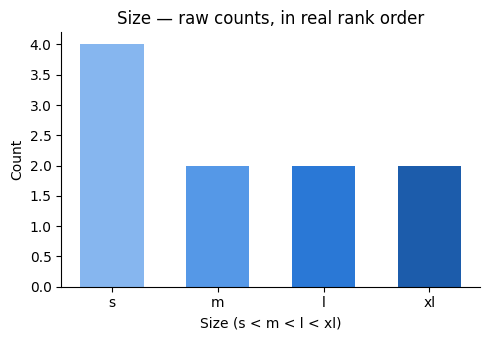

In [3]:
size_order = ["s", "m", "l", "xl"]
seq_ramp = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]  # sequential blue, light -> dark = low -> high rank

counts = df["Size"].value_counts().reindex(size_order)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(size_order, counts.values, color=seq_ramp, width=0.6)
ax.set_title("Size — raw counts, in real rank order")
ax.set_xlabel("Size (s < m < l < xl)")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Visualization 1 — raw counts, ordered correctly.** `value_counts()` on its own would
return categories sorted by frequency, not rank — `.reindex(size_order)` forces the
x-axis into the real `s → xl` order before plotting. The bars use one sequential blue
ramp, light to dark, so the color itself echoes the rank (lightest = smallest size) —
this is a single ordered series, not four unrelated categories, so it gets one hue
stepped by darkness rather than four different hues.

In [4]:
ord_data = [["s","m","l","xl"]]

The order `OrdinalEncoder` will assign codes in — a **list of lists**, one inner list
per column being encoded (only one column here, `Size`). Whatever order you write the
values in *is* the rank order the encoder learns: `s` here is first, so it becomes `0`.
`LabelEncoder` has no equivalent parameter — it can't be told an order at all.

In [5]:
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

Both imported here — `LabelEncoder` only to run the direct comparison below, not
because it's the right tool for this column.

In [6]:
oe = OrdinalEncoder(categories=ord_data)

Instantiate with the explicit order from above. Compare `10_Label_Encoding.ipynb`'s
`LabelEncoder()` — no arguments there, because there's nothing to configure; here the
`categories=` argument is the entire point of choosing this encoder.

In [7]:
oe.fit(df[["Size"]])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['s', 'm', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `max_categories` includes the category representing theinfrequent categories along with the frequent categories. If `None`,there is no limit to the number of output features.`max_categories` do **not** take into account missing or unknowncategories. Setting `unknown_value` or `encoded_missing_value` to aninteger will increase the number of unique integer codes by one each.This can result in up to `max_categories + 2` integer codes... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None


**`fit()` in isolation.** One difference from `LabelEncoder` worth catching early:
`df[["Size"]]` — **double** brackets, a DataFrame (2D), not `df["Size"]` (1D). `OrdinalEncoder`
is built for `X` (feature columns, possibly several at once); `LabelEncoder` is built for
`y` (a single target column) and only accepts 1D input. Passing a 1D column here raises a
`ValueError` — a genuinely common gotcha when switching between the two.

In [8]:
df["Size_En"]= oe.transform(df[["Size"]])
df

,Size,Size_En
0,s,0.0
1,m,1.0
2,l,2.0
3,xl,3.0
4,s,0.0
5,s,0.0
6,m,1.0
7,l,2.0
8,xl,3.0
9,s,0.0


**`transform()` in isolation** — codes now follow the real order: `s=0, m=1, l=2, xl=3`,
a perfect staircase. Kept as two separate calls here for the same reason `10` split
`fit`/`transform`: `fit()` once on training data, `transform()` reused unchanged on
validation/test.

In [9]:
le_check = LabelEncoder()
le_check.fit(df["Size"])
label_codes = le_check.transform(size_order)          # what LabelEncoder assigns to s, m, l, xl
ordinal_codes = oe.transform(pd.DataFrame({"Size": size_order}))[:, 0]  # what OrdinalEncoder assigns

print("LabelEncoder classes_ (alphabetical):", le_check.classes_)
print("LabelEncoder codes for s, m, l, xl:  ", label_codes)
print("OrdinalEncoder codes for s, m, l, xl:", ordinal_codes)

LabelEncoder classes_ (alphabetical): ['l' 'm' 's' 'xl']
LabelEncoder codes for s, m, l, xl:   [2 1 0 3]
OrdinalEncoder codes for s, m, l, xl: [0. 1. 2. 3.]


**The concrete difference, side by side.** `LabelEncoder` sorts alphabetically —
`classes_` comes back `['l', 'm', 's', 'xl']` — so it assigns `l=0, m=1, s=2, xl=3`.
Read against the real rank (`s < m < l < xl`), that's backwards and scrambled: it
claims the *largest* size (`l`) is the *smallest* code. `OrdinalEncoder`, told the
real order explicitly, gives the correct staircase `s=0, m=1, l=2, xl=3`. Same
column, same five lines of setup, two completely different — and only one
*correct* — numeric relationships. Visualized next.

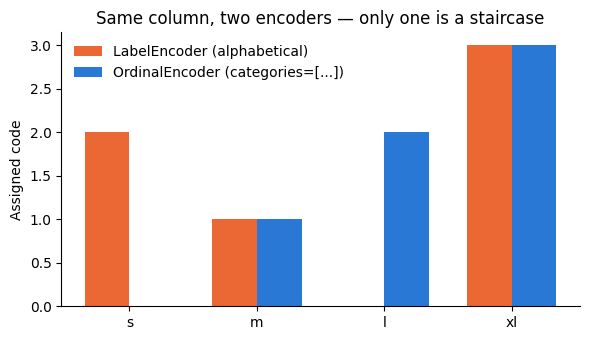

In [10]:
x = np.arange(len(size_order))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(x - width/2, label_codes, width, label="LabelEncoder (alphabetical)", color="#eb6834")
ax.bar(x + width/2, ordinal_codes, width, label="OrdinalEncoder (categories=[...])", color="#2a78d6")
ax.set_xticks(x)
ax.set_xticklabels(size_order)
ax.set_ylabel("Assigned code")
ax.set_title("Same column, two encoders — only one is a staircase")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Visualization 2 — why the difference matters.** Orange (`LabelEncoder`) zigzags;
blue (`OrdinalEncoder`) climbs in a straight staircase matching `s < m < l < xl`. Two
series here (two different *encoders*, i.e. two different identities), so they get
two distinct hues with a legend — not a light-to-dark ramp, since these aren't steps
of one ordered thing the way the raw-count chart was.

In [11]:
df1 = pd.DataFrame({"Size":["s","m","l","xl","s","s","m","l","xl","s"]})

Same duality `10_Label_Encoding.ipynb` showed for `fit_transform` vs. separate
`fit`/`transform` — here it's `OrdinalEncoder` vs. a plain Python dict + `.map()`,
both expressing the identical mapping.

In [12]:
ord_data1= {"s":0,"m":1,"l":2,"xl":3}

A hand-written lookup table saying exactly the same thing as `ord_data = [["s","m","l","xl"]]`
above, just as a dict instead of an ordered list.

In [13]:
df1["Size_EN_MAP"] = df1["Size"].map(ord_data1)
df1

,Size,Size_EN_MAP
0,s,0
1,m,1
2,l,2
3,xl,3
4,s,0
5,s,0
6,m,1
7,l,2
8,xl,3
9,s,0


`.map()` looks up every value in `ord_data1` and substitutes its code — identical
output to `OrdinalEncoder` above (`s=0, m=1, l=2, xl=3`). The trade-off: `.map()` is
one line and needs no import, but it's entirely manual — any value *not* in the dict
silently becomes `NaN`, with no warning. `OrdinalEncoder` gives the same result plus
the sklearn safety net: `handle_unknown="use_encoded_value", unknown_value=np.nan`
(or an error, by default) for values it wasn't fit on, and it drops straight into a
`Pipeline`/`ColumnTransformer` the way a plain dict can't.

## Real Data — Two Columns, Two Different Situations

`loans.csv` again. Two columns this time:

- **`Property_Area`** — `Rural`/`Semiurban`/`Urban`. Same column `09` and `10` used —
  it's **nominal**, not ordinal, but it's encoded here anyway to fix a real bug that
  was in the original version of this notebook (see the callout below).
- **`Dependents`** — `0`/`1`/`2`/`3+`. This one *is* genuinely ordinal: more
  dependents is a real, ordered quantity.

In [14]:
dataset = pd.read_csv("loans.csv")
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001001,Male,Yes,0,Not Graduate,No,1686.0,1020,80.0,360.0,1.0,Semiurban,Y
1,LP001002,Male,Yes,0,Not Graduate,No,2437.0,1201,122.0,360.0,1.0,Urban,Y
2,LP001003,Female,No,0,Graduate,No,8313.0,1065,319.0,360.0,1.0,Urban,Y
3,LP001004,Male,Yes,0,Graduate,No,5069.0,0,218.0,360.0,1.0,Semiurban,Y
4,LP001005,Male,No,2,Graduate,No,3002.0,2283,194.0,360.0,0.0,Urban,N


Loading the same dataset `09` and `10` used.

In [15]:
dataset["Property_Area"].unique()

<StringArray>
['Semiurban', 'Urban', nan, 'Rural']
Length: 4, dtype: str

9 missing values hiding in here (per `09_one_hot_encoding.ipynb`'s `isnull().sum()`
check) — same as before, has to be imputed *before* encoding.

In [16]:
dataset["Property_Area"] = dataset["Property_Area"].fillna(dataset["Property_Area"].mode()[0])
dataset["Property_Area"].unique()

<StringArray>
['Semiurban', 'Urban', 'Rural']
Length: 3, dtype: str

**The bug fix.** The original version of this cell was:

```python
dataset["Property_Area"].fillna(dataset["Property_Area"].mode()[0], inplace=True)
```

That's the exact copy-on-write gotcha `09_one_hot_encoding.ipynb` already called out
for `Gender`: `dataset["Property_Area"].fillna(..., inplace=True)` mutates a **throwaway
copy** of the column, not `dataset` itself — pandas even raises a `ChainedAssignmentError`
warning about it. `dataset["Property_Area"]` was left with `NaN` still in it, and two
cells later `OrdinalEncoder(categories=[["Rural","Semiurban","Urban"]]).fit_transform(...)`
crashed with `ValueError: Found unknown categories [nan] in column 0 during fit` — the
explicit `categories` list has no entry for `nan`, so the encoder correctly refuses to
guess. Reassigning (`dataset["Property_Area"] = dataset["Property_Area"].fillna(...)`)
writes the result back into the real column, so `unique()` above now comes back with
**no `nan`** — the fix is confirmed before the encoder ever runs, not after it fails.

In [17]:
en_data_ord = [["Rural","Semiurban","Urban"]]

No real rank between these three (nominal — `09` one-hot-encoded this exact column
for that reason), but an explicit order still has to be supplied for `OrdinalEncoder`
to run at all. Picked arbitrarily here purely to demonstrate the mechanics on a
familiar column, now that the missing-value bug is fixed.

In [18]:
oen = OrdinalEncoder(categories=en_data_ord)
dataset["Property_Area"] = oen.fit_transform(dataset[["Property_Area"]])
dataset["Property_Area"].head(10)

0    1.0
1    2.0
2    2.0
3    1.0
4    2.0
5    1.0
6    0.0
7    2.0
8    1.0
9    1.0
Name: Property_Area, dtype: float64

Runs cleanly now — no `nan` left to trip the encoder. (The original also had a second
bug on this line, `dataset[10]` instead of showing the encoded column — indexing a
DataFrame with a bare integer like that raises `KeyError` unless a column is literally
named `10`. Fixed to `dataset["Property_Area"].head(10)`, which actually shows the
result: `Rural→0, Semiurban→1, Urban→2`.)

**Worth restating:** this column being encodable now doesn't make label/ordinal
encoding the *right* choice for it in a real model — see the comparison table further
down. It's nominal; `09`'s one-hot encoding is still the safer default for a
linear/distance-based model.

### `Dependents` — the genuinely ordinal one

Unlike `Property_Area`, this column has a real order: `0 < 1 < 2 < 3+` dependents
is an actual ordered quantity, not an arbitrary label. This is the kind of column
`OrdinalEncoder` was built for.

In [19]:
dataset["Dependents"].value_counts(dropna=False)

Dependents
0      356
2      108
1       82
3+      57
NaN     15
Name: count, dtype: int64

15 missing values. Same rule as always: impute before encoding, using the same
reassignment pattern (not `inplace=True`) fixed above.

In [20]:
dataset["Dependents"] = dataset["Dependents"].fillna(dataset["Dependents"].mode()[0])
dataset["Dependents"].unique()

<StringArray>
['0', '2', '1', '3+']
Length: 4, dtype: str

`NaN` gone, mode-filled with the most common value (`"0"`).

In [21]:
dep_order = [["0", "1", "2", "3+"]]
oe_dep = OrdinalEncoder(categories=dep_order)
dataset["Dependents_En"] = oe_dep.fit_transform(dataset[["Dependents"]])
dataset[["Dependents", "Dependents_En"]].head(10)

,Dependents,Dependents_En
0,0,0.0
1,0,0.0
2,0,0.0
3,0,0.0
4,2,2.0
5,0,0.0
6,0,0.0
7,0,0.0
8,0,0.0
9,0,0.0


A dedicated encoder instance (`oe_dep`) with its own `categories=` — same pattern as
`la`/`le2` getting their own `LabelEncoder` in `10`, one encoder per column. `"0" → 0,
"1" → 1, "2" → 2, "3+" → 3`, the real order preserved exactly, unlike what `LabelEncoder`
would have done here too (alphabetical on these strings happens to *coincidentally*
match, since `"0" < "1" < "2" < "3+"` sorts the same both ways — but that's luck, not a
guarantee, which is exactly why `categories=` is still the safer, explicit choice).

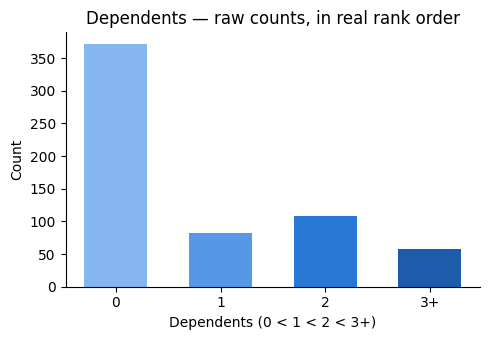

In [22]:
dep_order_list = ["0", "1", "2", "3+"]
dep_ramp = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab"]
dep_counts = dataset["Dependents"].value_counts().reindex(dep_order_list)

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(dep_order_list, dep_counts.values, color=dep_ramp, width=0.6)
ax.set_title("Dependents — raw counts, in real rank order")
ax.set_xlabel("Dependents (0 < 1 < 2 < 3+)")
ax.set_ylabel("Count")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Visualization 3 — the real-data version of Visualization 1.** Same sequential
blue ramp, light-to-dark following the real rank, now on `loans.csv` instead of the
toy example — most applicants have 0 dependents, tapering off through `3+`.

## Label Encoding vs. One-Hot Encoding vs. Ordinal Encoding

| | `LabelEncoder` (`10`) | `OneHotEncoder` (`09`) | `OrdinalEncoder` (this notebook) |
|---|---|---|---|
| **Output** | 1 column, integer codes | *n* (or *n*-1) binary columns | 1 column, integer codes |
| **Who sets the order** | The encoder — always alphabetical | n/a — no order implied | **You** — via `categories=` |
| **Order implied?** | Yes, but arbitrary | No | Yes, and (if you set it right) real |
| **Input shape** | 1D — a single column (`df["col"]`) | 2D — one or more columns | 2D — one or more columns |
| **Intended for** | The target column `y` | Nominal feature columns `X` | Ordinal feature columns `X` |
| **Right for** | Encoding `y` in classification | Nominal `X`, linear/distance-based models | Ordinal `X`, any model |
| **Wrong for** | Nominal `X` into linear/distance-based models | High-cardinality nominal columns | Nominal `X` with no real order to supply |
| **Unseen category at transform time** | Errors | `handle_unknown="ignore"` available | `handle_unknown="use_encoded_value"` + `unknown_value=` available |
| **`loans.csv` example** | — (not used on `X` here) | `Gender`, `Married` (`09`) | `Dependents` (real rank) — `Property_Area` here only to show mechanics |

The one-line version: **all three answer "how do I turn text into numbers,"
and only `OrdinalEncoder` lets you also answer "in what order."**

## When (and Why) to Use Ordinal Encoding

**Use it when:**
- **The category has a real, known rank** and you can write that order down —
  sizes, ratings (`Low/Medium/High`), education levels, `Dependents`-style counts
  bucketed as strings. The whole benefit over `LabelEncoder` is that you supply the
  order instead of hoping alphabetical sort happens to match reality.
- **You need more than one ordinal column encoded together** — `OrdinalEncoder`
  takes 2D input and a `categories=` list-of-lists, so one instance can fit several
  columns at once (each with its own order), where `LabelEncoder` needs a separate
  instance per column since it only accepts 1D.
- **Production robustness matters** — `handle_unknown="use_encoded_value",
  unknown_value=np.nan` handles a category showing up at inference time that
  training never saw, without crashing the pipeline (a plain `.map()` dict just
  silently returns `NaN` with no such configuration).

**Think twice when:**
- **There's no real order** — forcing `categories=` on a nominal column (like
  `Property_Area` above) doesn't make the order real; it just picks *one* arbitrary
  order instead of the alphabetical one `LabelEncoder` would have picked. One-hot
  encoding (`09`) is still the honest choice for nominal data going into a
  linear/distance-based model.
- **The order is debatable** — if two people would rank the categories differently,
  that's a sign the "order" is more nominal than ordinal in practice; encoding it
  as ordinal bakes in one arbitrary opinion as if it were fact.

**Implementation notes:**
- `categories=` must list **every** value that will ever appear, in rank order, as
  a list of lists (one inner list per column) — a value missing from that list is
  treated as *unknown*, not silently appended.
- Always pass a 2D slice (`df[["col"]]`, double brackets), never a 1D `df["col"]` —
  the single most common `OrdinalEncoder` error.
- Impute missing values *before* fitting — an explicit `categories=` list has no
  slot for `NaN` unless you deliberately add one, so a leftover `NaN` (from a bug
  like the one fixed above, or from skipping imputation entirely) raises
  `ValueError: Found unknown categories [nan]` at fit time.